In [1]:
pip install numpy pandas scikit-learn imbalanced-learn matplotlib seaborn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

In [ ]:
import pandas as pd

DATA_PATH = "creditcard.csv"   
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head())
print(df['Class'].value_counts())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
X = df.drop(columns=['Class'])  
y = df['Class']                 

# 2. Drop 'Time' column (optional but common)
X = X.drop(columns=['Time'])

# 3. Scale 'Amount' column (others are already PCA-transformed)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# 4. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.linear_model import LogisticRegression

# Create the model
log_reg = LogisticRegression(
    max_iter=500,              # Increase iterations for convergence
    class_weight='balanced',   # Tells model to pay more attention to minority class (fraud)
    random_state=42
)

# Train the model
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

Accuracy: 0.9745619886942172

Classification Report:
               precision    recall  f1-score   support

           0     0.9999    0.9747    0.9871     56864
           1     0.0588    0.9184    0.1105        98

    accuracy                         0.9746     56962
   macro avg     0.5293    0.9465    0.5488     56962
weighted avg     0.9982    0.9746    0.9856     56962



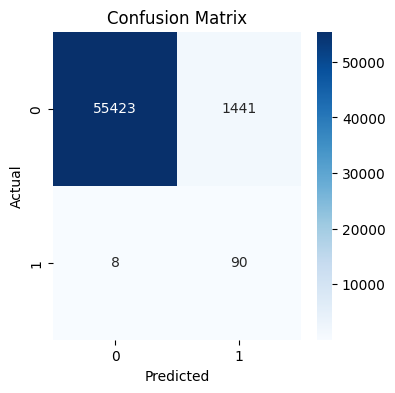

ROC-AUC Score: 0.9714465520310545


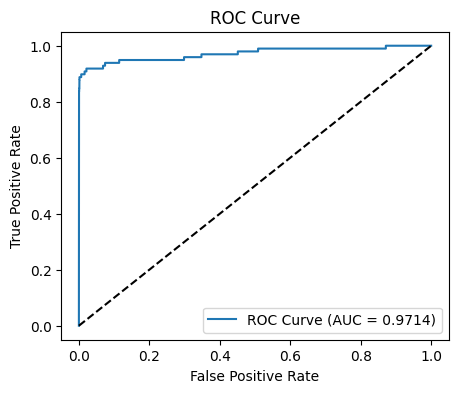

In [9]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]  # probability of fraud (Class=1)

# 2. Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# 3. Classification report: precision, recall, F1
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# 4. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. ROC-AUC score
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", auc)

# 6. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
import joblib
import os

# Create folders if they don't exist
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# Save model and scaler
joblib.dump(log_reg, "models/log_reg_fraud.pkl")
joblib.dump(scaler, "models/amount_scaler.pkl")

# Save evaluation metrics to a text file
with open("reports/metrics.txt", "w") as f:
    f.write("Logistic Regression Fraud Detection Report\n")
    f.write(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    f.write(f"ROC-AUC: {auc:.4f}\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_test, y_pred))
    f.write("\nConfusion Matrix:\n")
    f.write(np.array2string(confusion_matrix(y_test, y_pred)))